In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_analysis_utils import Univariate as univ

sns.set_theme(palette='Set1', style='whitegrid', context='notebook')


In [2]:
data = pd.read_csv('PrePlacement.csv')
data.drop('sl_no', axis=1, inplace=True)
data


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


### DisPlot

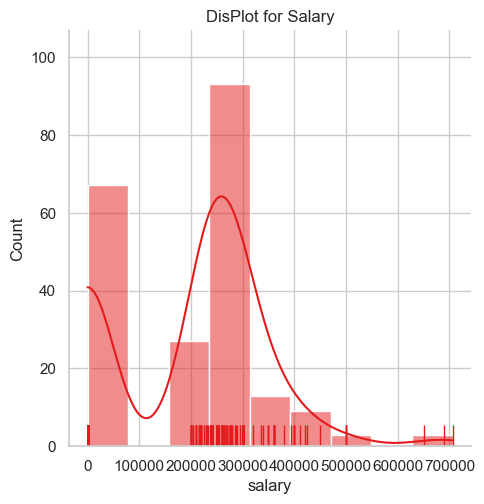

In [3]:
# Univariate
# Numeric

sns.displot(data, x='salary', kde=True, rug=True, rug_kws={'height':0.05})
plt.title('DisPlot for Salary')
plt.show()


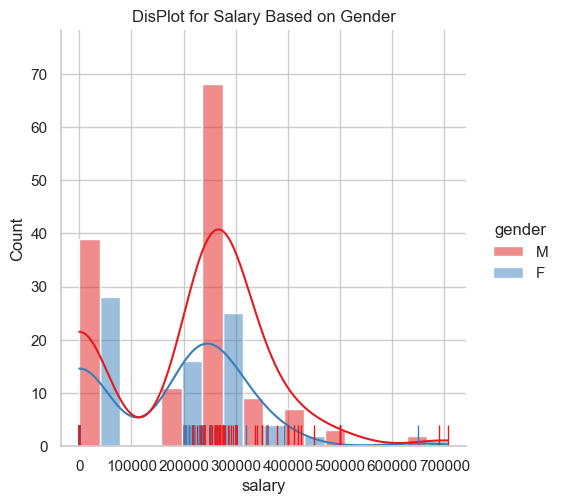

In [4]:
# Bivariate
# Numeric + Categoric

sns.displot(data, x='salary', hue='gender', kde=True, rug=True, rug_kws={'height':0.05}, multiple='dodge')
plt.title('DisPlot for Salary Based on Gender')
plt.show()


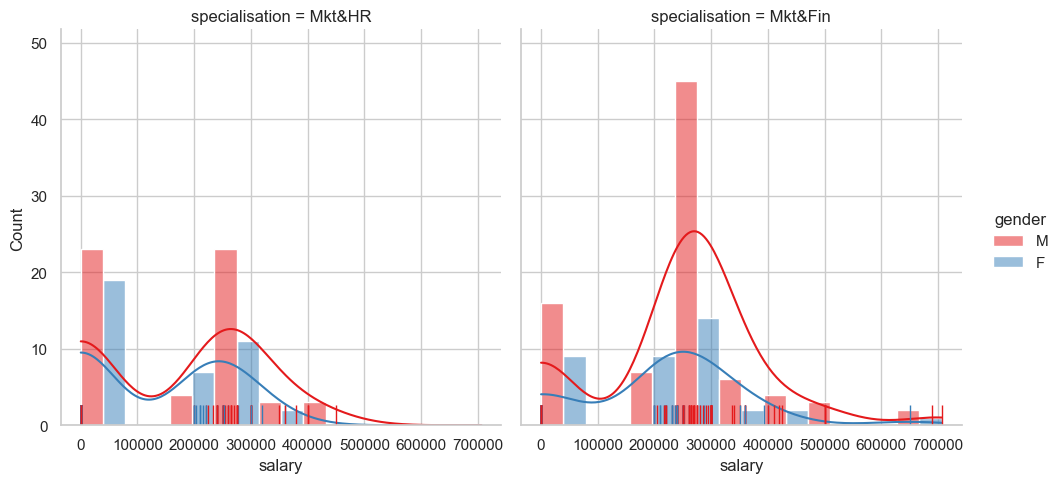

In [5]:
# Multivariate
# Numeric + 2 Categoric

sns.displot(data, x='salary', hue='gender', col='specialisation', kde=True, rug=True, rug_kws={'height':0.05}, multiple='dodge')
plt.show()


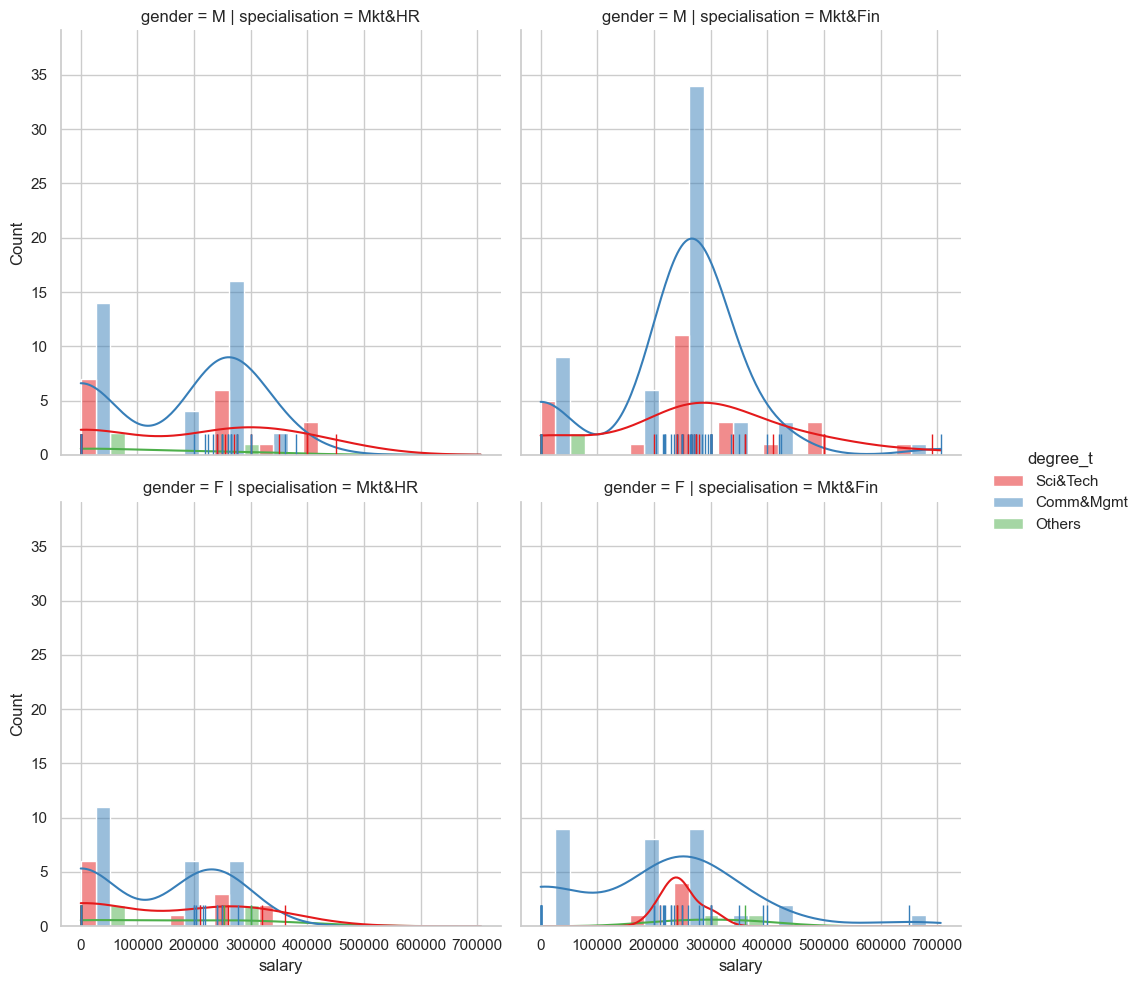

In [6]:
# Multivariate
# Numeric + 3 Categoric

sns.displot(data, x='salary', hue='degree_t', row='gender', col='specialisation', kde=True, rug=True, rug_kws={'height':0.05}, multiple='dodge')
plt.show()


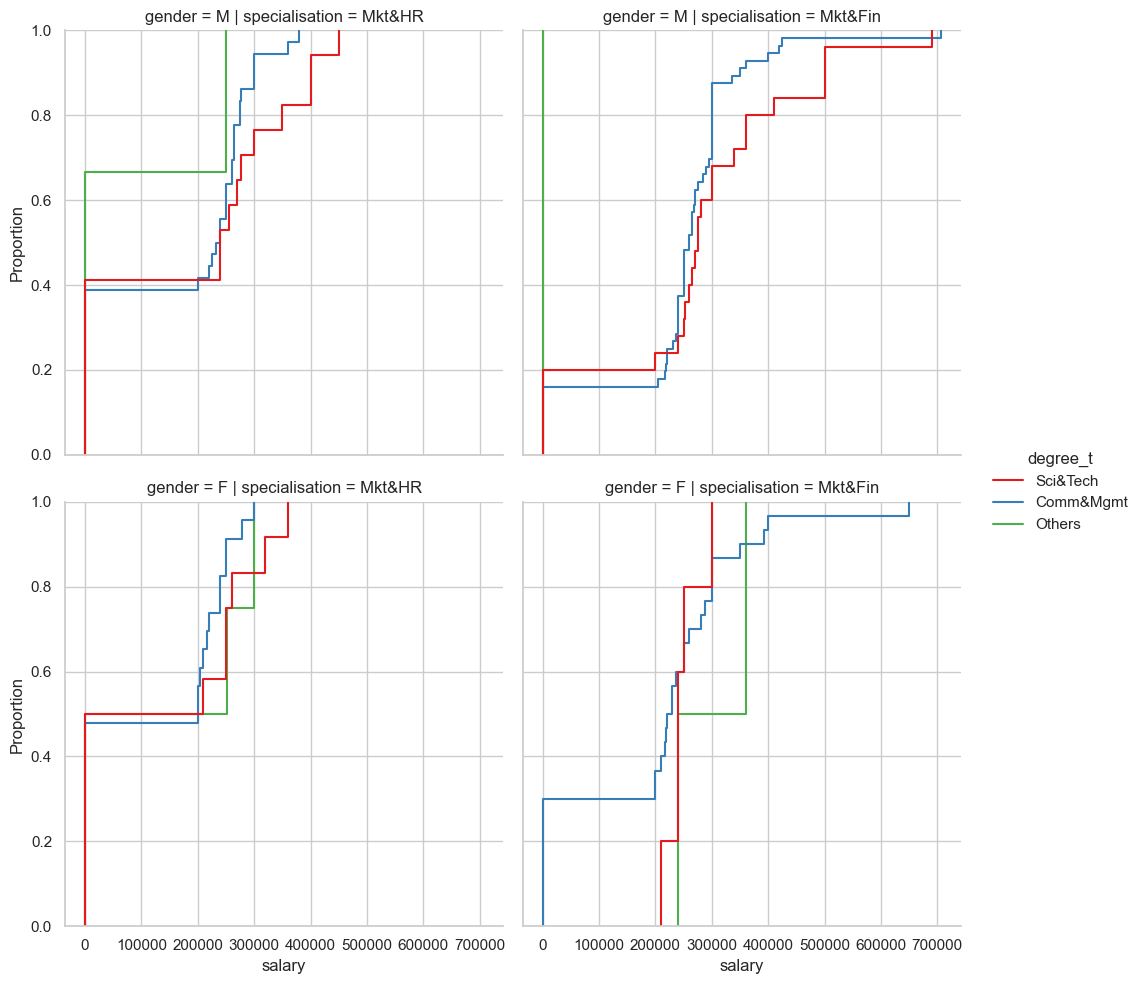

In [7]:
# Multivariate
# Numeric + 3 Categoric

sns.displot(data, x='salary', hue='degree_t', row='gender', col='specialisation', kind='ecdf')
plt.show()


### JointPlot

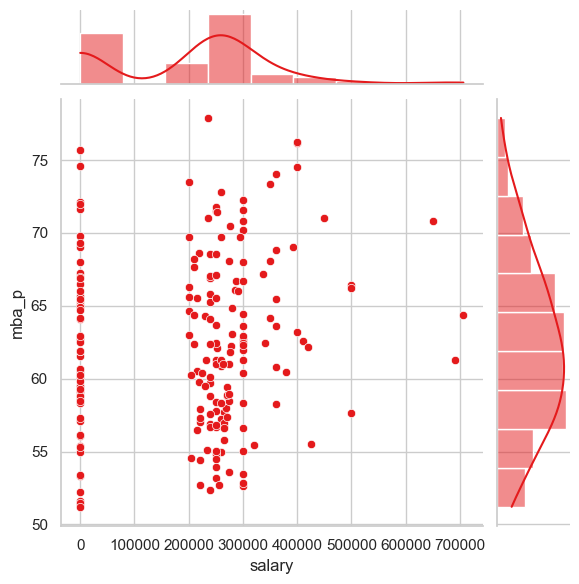

In [8]:
# Bivariate
# 2 Numeric

sns.jointplot(data, x='salary', y='mba_p', marginal_kws={'kde':True})
plt.show()


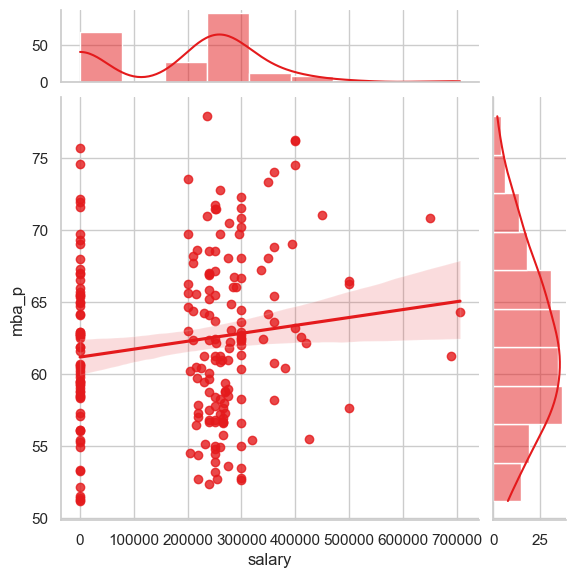

In [9]:
# Bivariate
# 2 Numeric

sns.jointplot(data, x='salary', y='mba_p', kind='reg', marginal_ticks=True)
plt.show()


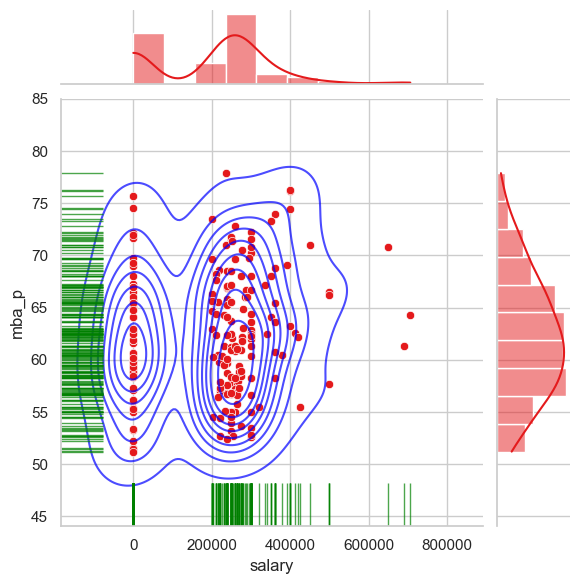

In [10]:
# Multivariate
# 2 Numeric + Categoric

fig1= sns.jointplot(data, x='salary', y='mba_p', marginal_kws={'kde':True})
fig1.plot_joint(sns.kdeplot, color='blue', alpha=0.7)
fig1.plot_joint(sns.rugplot, height=0.1, color='green', alpha=0.7)
plt.show()


### PairPlot

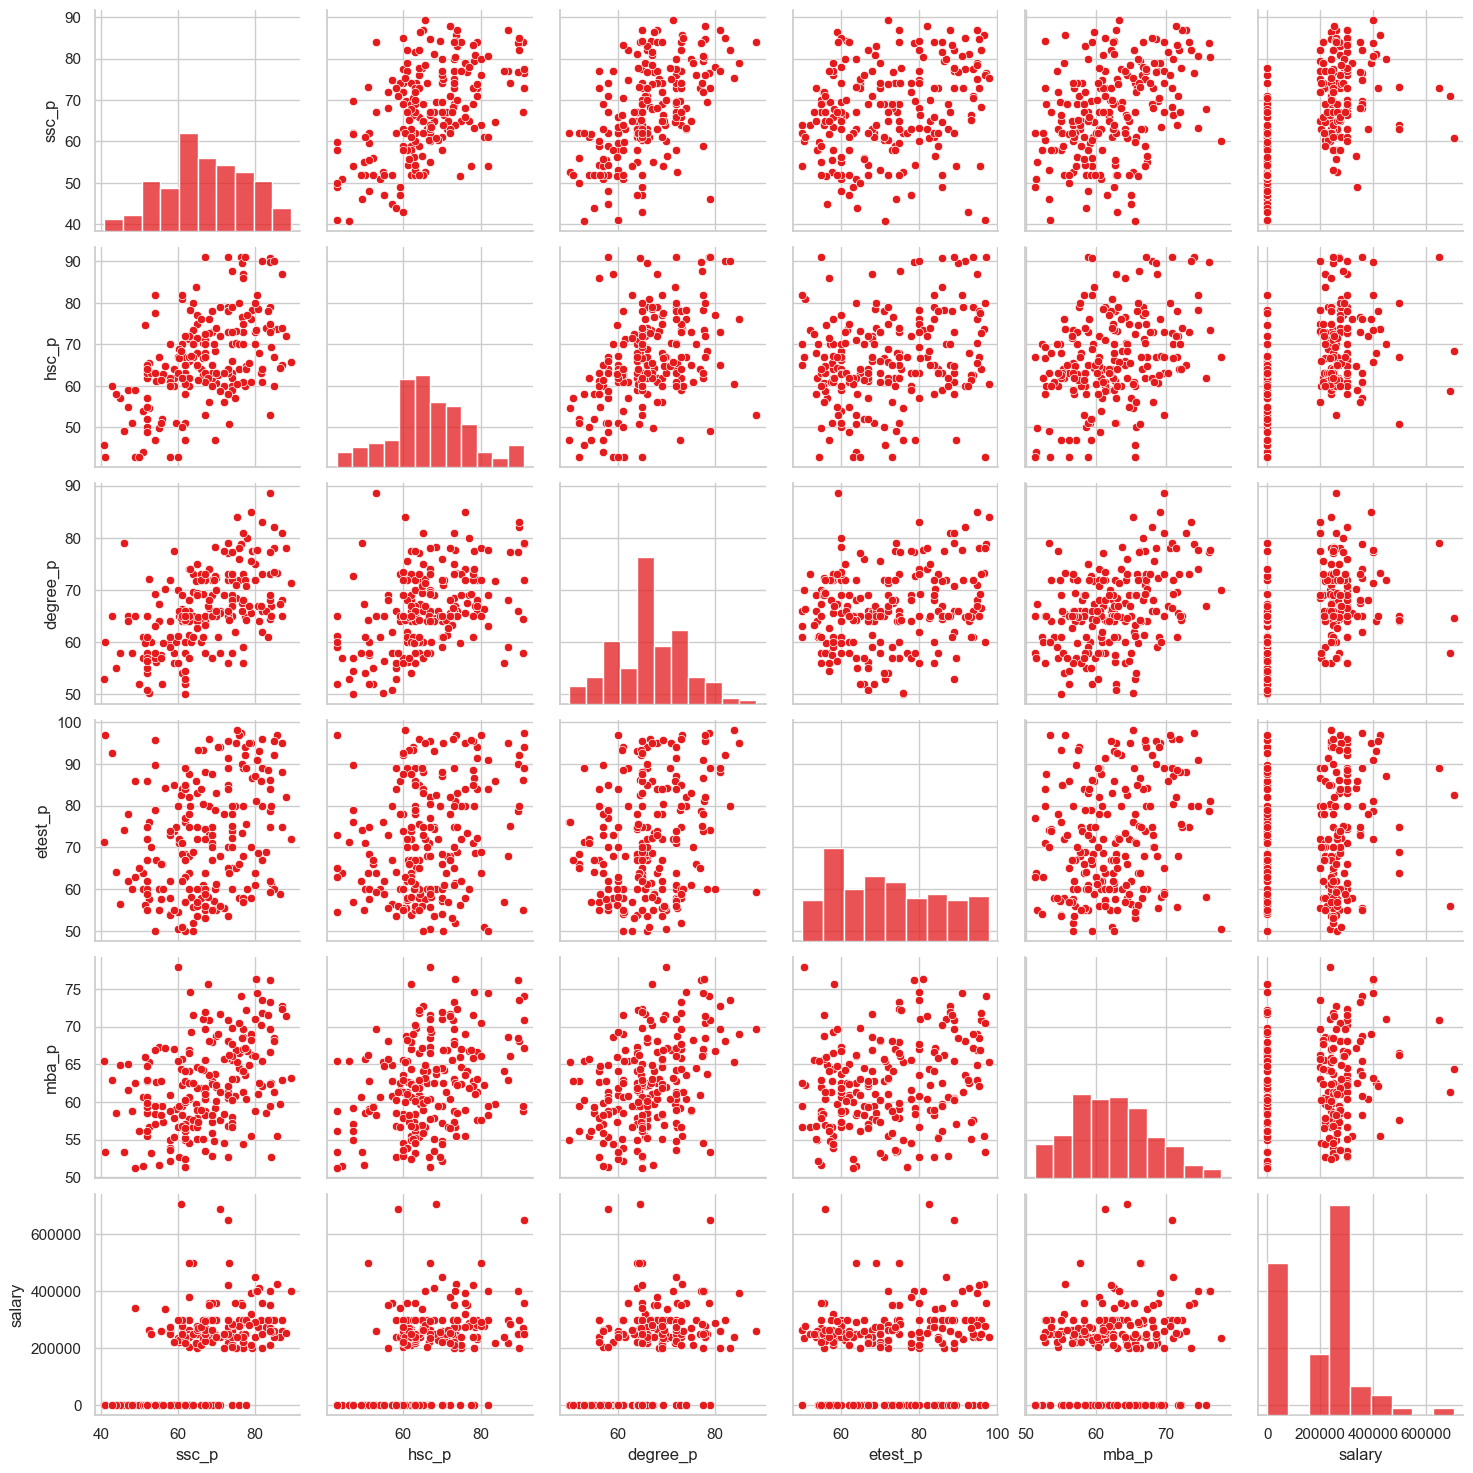

In [11]:
# Multivariate
# Numeric

sns.pairplot(data)
plt.show()


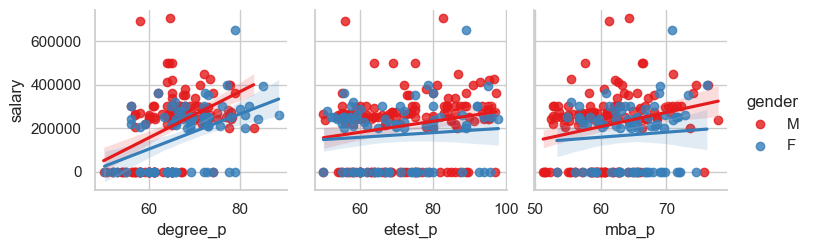

In [12]:
# Multivariate
# Numeric + 1 Categoric

sns.pairplot(data, x_vars=['degree_p', 'etest_p','mba_p'], y_vars='salary', hue='gender', kind='reg')
plt.show()


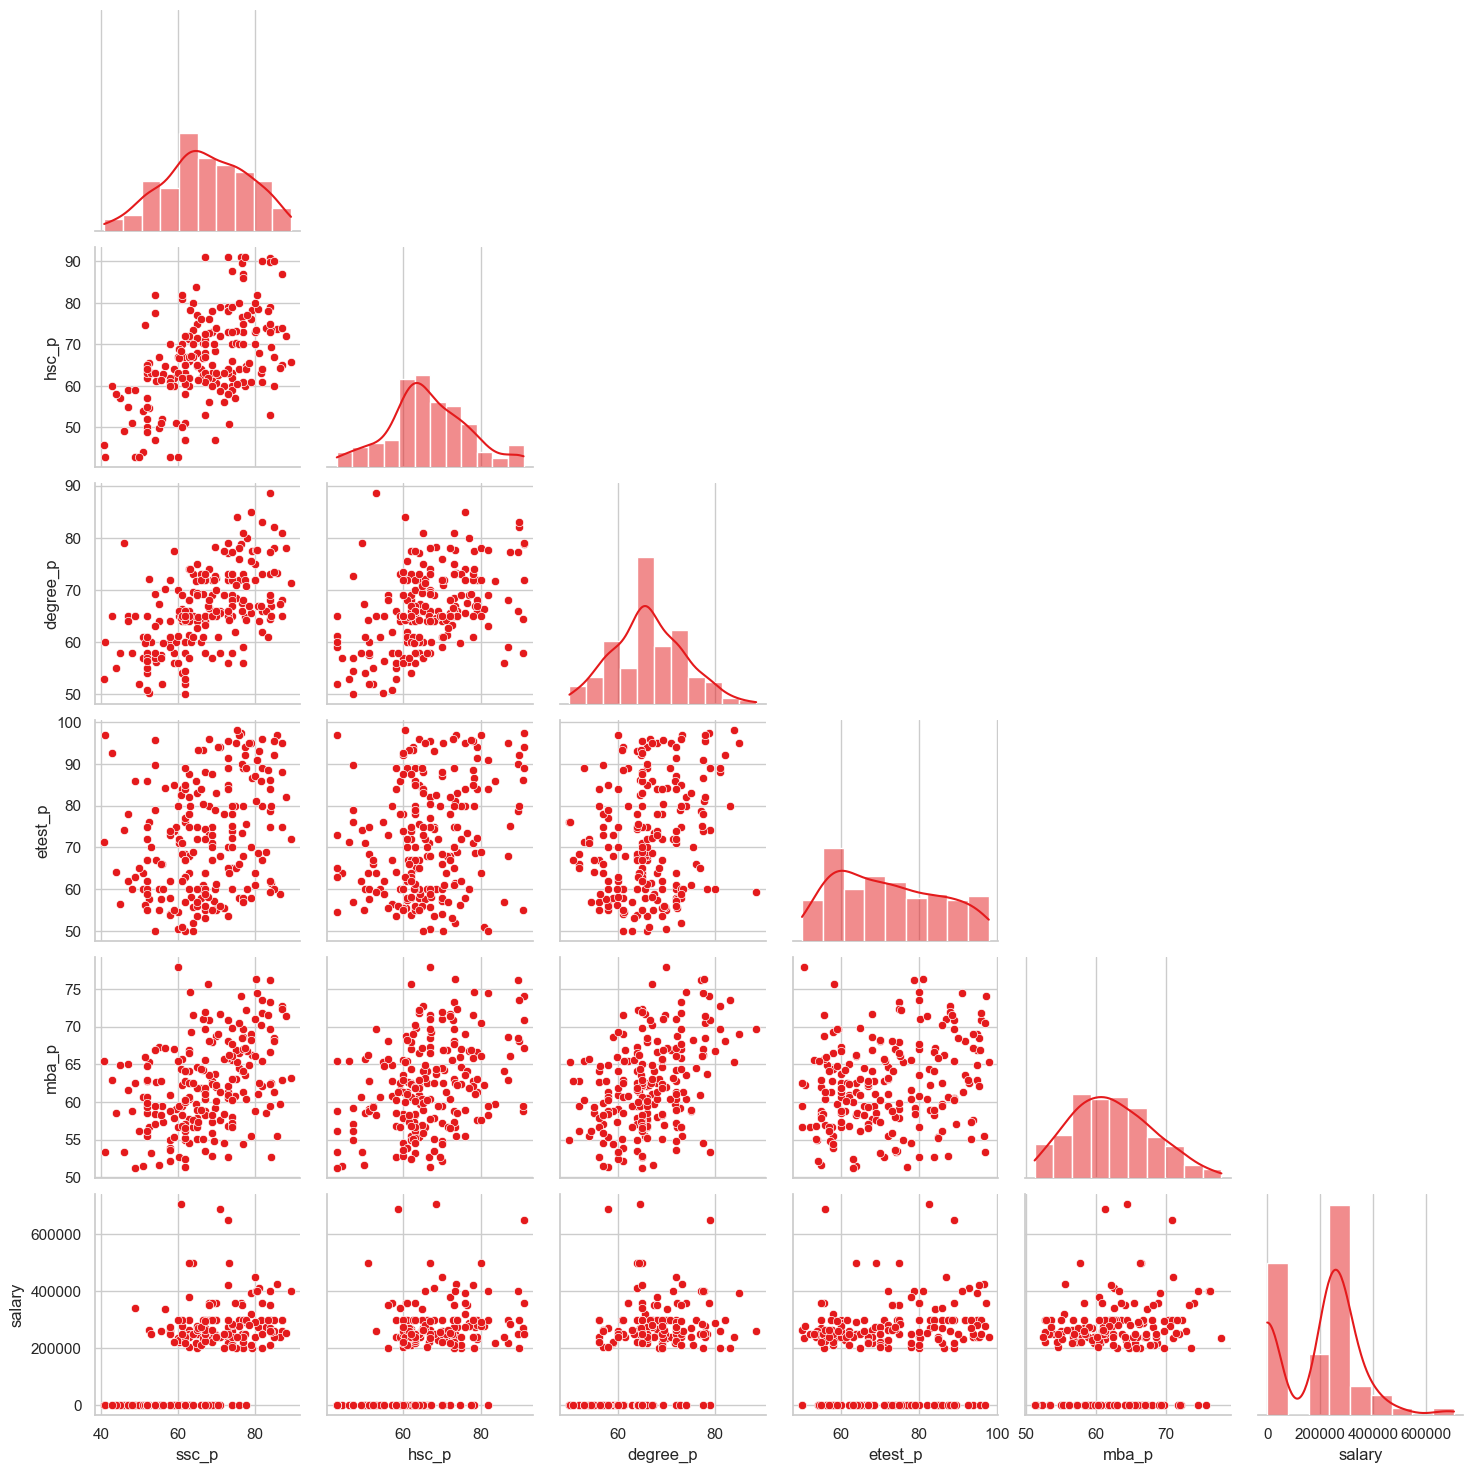

In [13]:
sns.pairplot(data, corner=True, diag_kws={'kde':True})
plt.show()


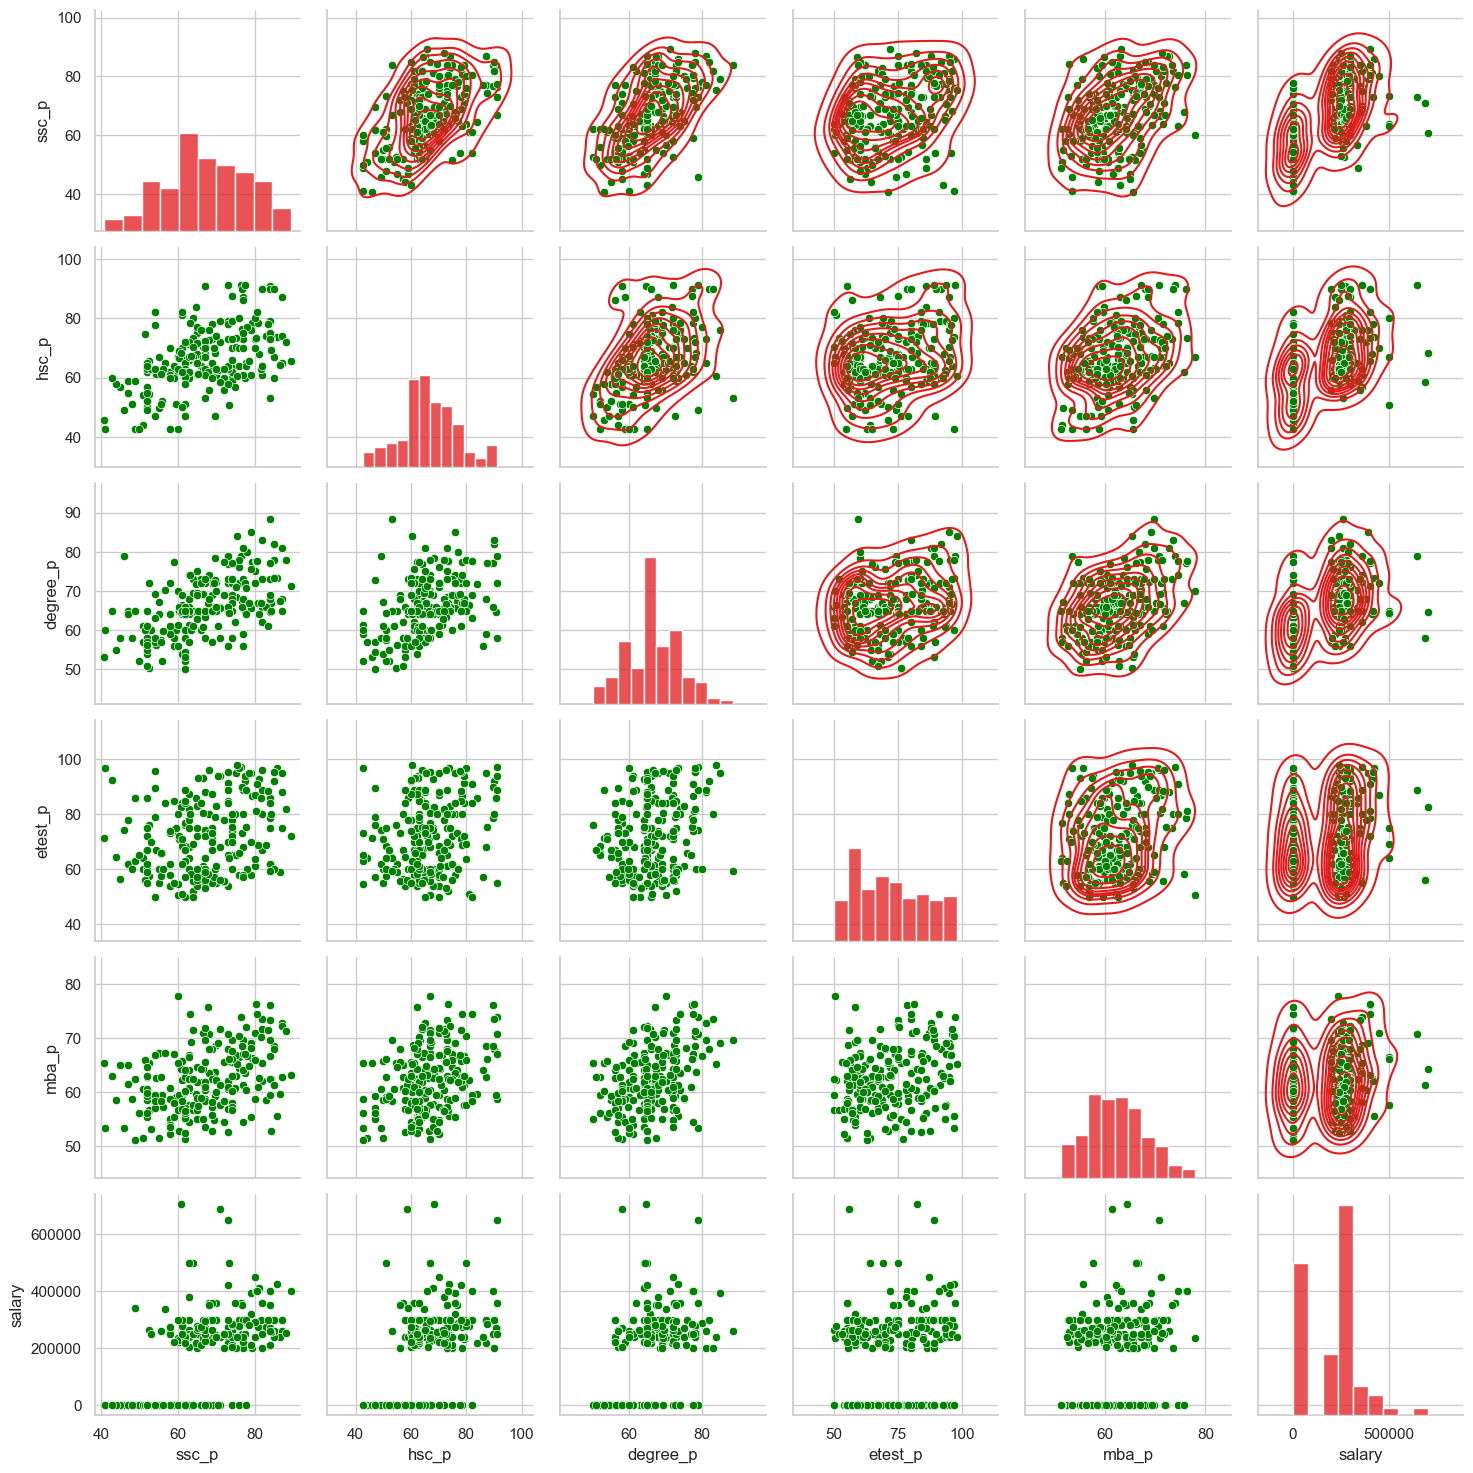

In [14]:
fig2=sns.pairplot(data, plot_kws={'color':'green'})
fig2.map_upper(sns.kdeplot)
plt.show()


### ScatterPlots


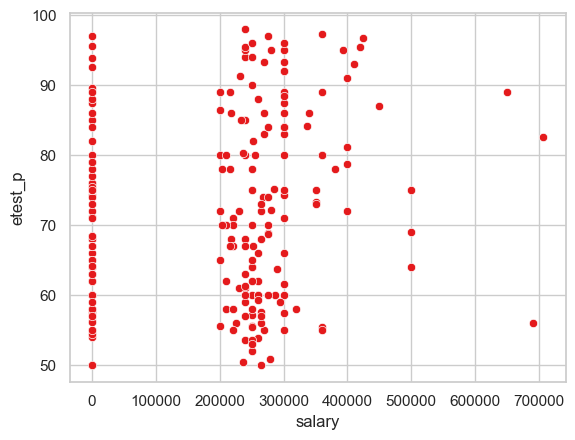

In [15]:
# Bivariate
# Numerical

sns.scatterplot(data, x='salary', y='etest_p')
plt.show()


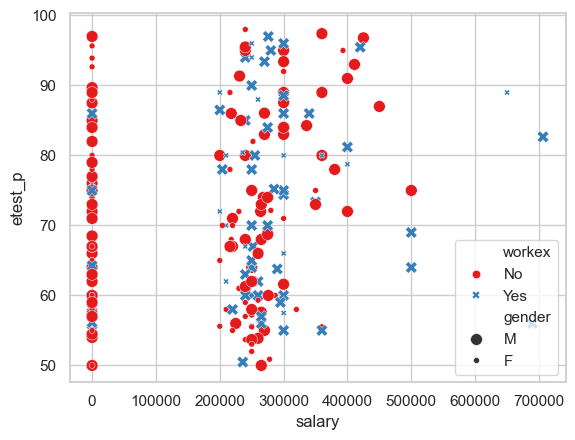

In [16]:
# Multivariate
# 2 Numerical + 2 Categorical

sns.scatterplot(data, x='salary', y='etest_p', style='workex', hue='workex', size='gender')
plt.show()


### LinePlot

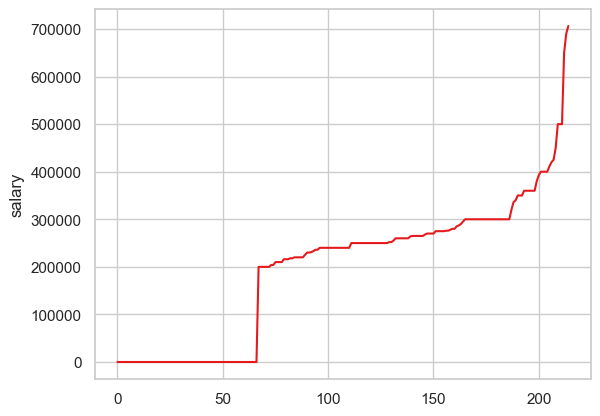

In [17]:
# Uivariate
# Numeric

line_dataset = data.sort_values('salary', ignore_index=True)
sns.lineplot(line_dataset, x=range(0,len(data)), y='salary')
plt.show()


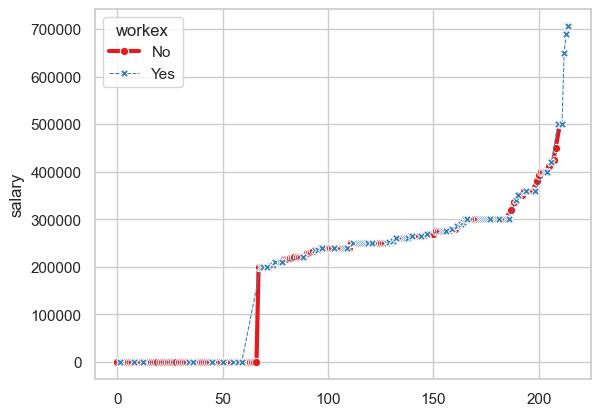

In [18]:
# Bivariate
# Numeric + Categoric

line_dataset = data.sort_values('salary', ignore_index=True)
sns.lineplot(line_dataset, x=range(0,len(data)), y='salary', style='workex', hue='workex', size='workex', markers=True)
plt.show()


### RelPlot

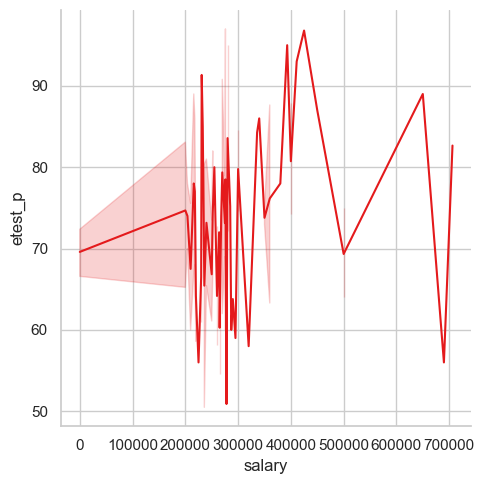

In [19]:
# Bivariate
# Numeric + Numeric / Date

sns.relplot(data, x='salary', y='etest_p', kind='line')
plt.show()


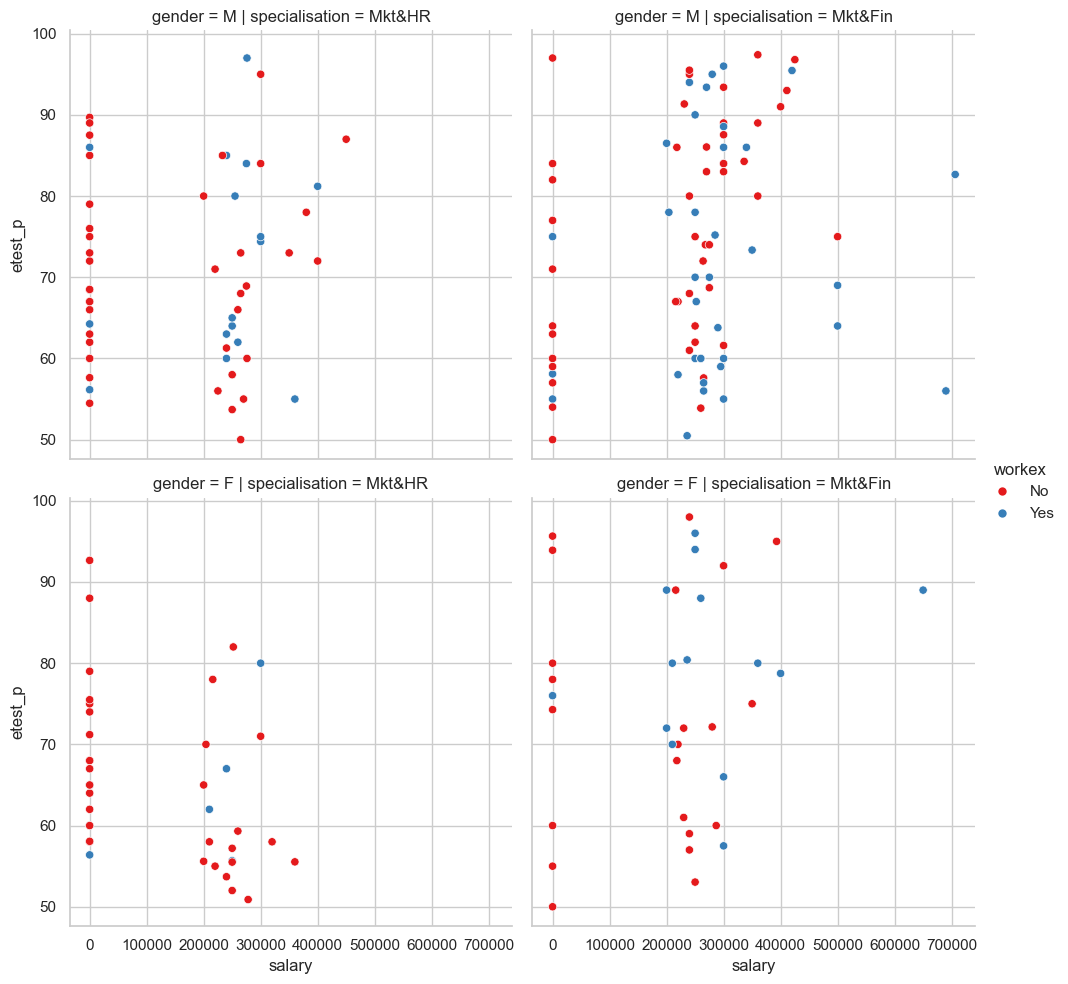

In [20]:
# Bivariate
# Numeric + Numeric / Date

sns.relplot(data, x='salary', y='etest_p', hue='workex', col='specialisation', row='gender')
plt.show()


### PointPlot

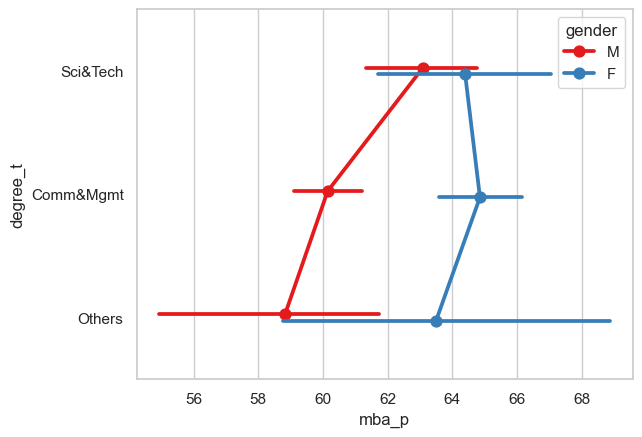

In [21]:
# Multivariate
# Numeric + 2 Categoric

sns.pointplot(data, x='mba_p', y='degree_t', hue='gender', dodge=True)
plt.show()


### RegPlot

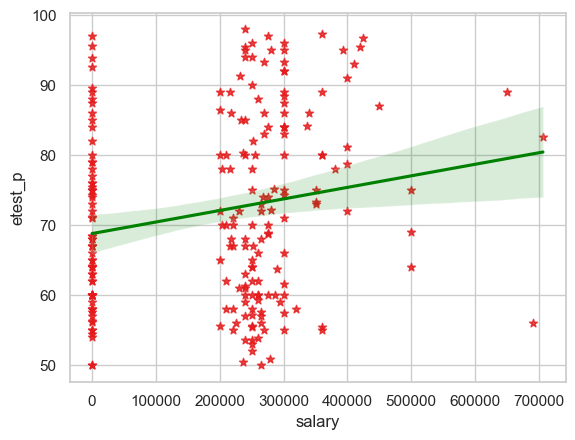

In [22]:
sns.regplot(data, x='salary', y='etest_p', marker='*', line_kws=dict(color='green'))
plt.show()


### LmPlot

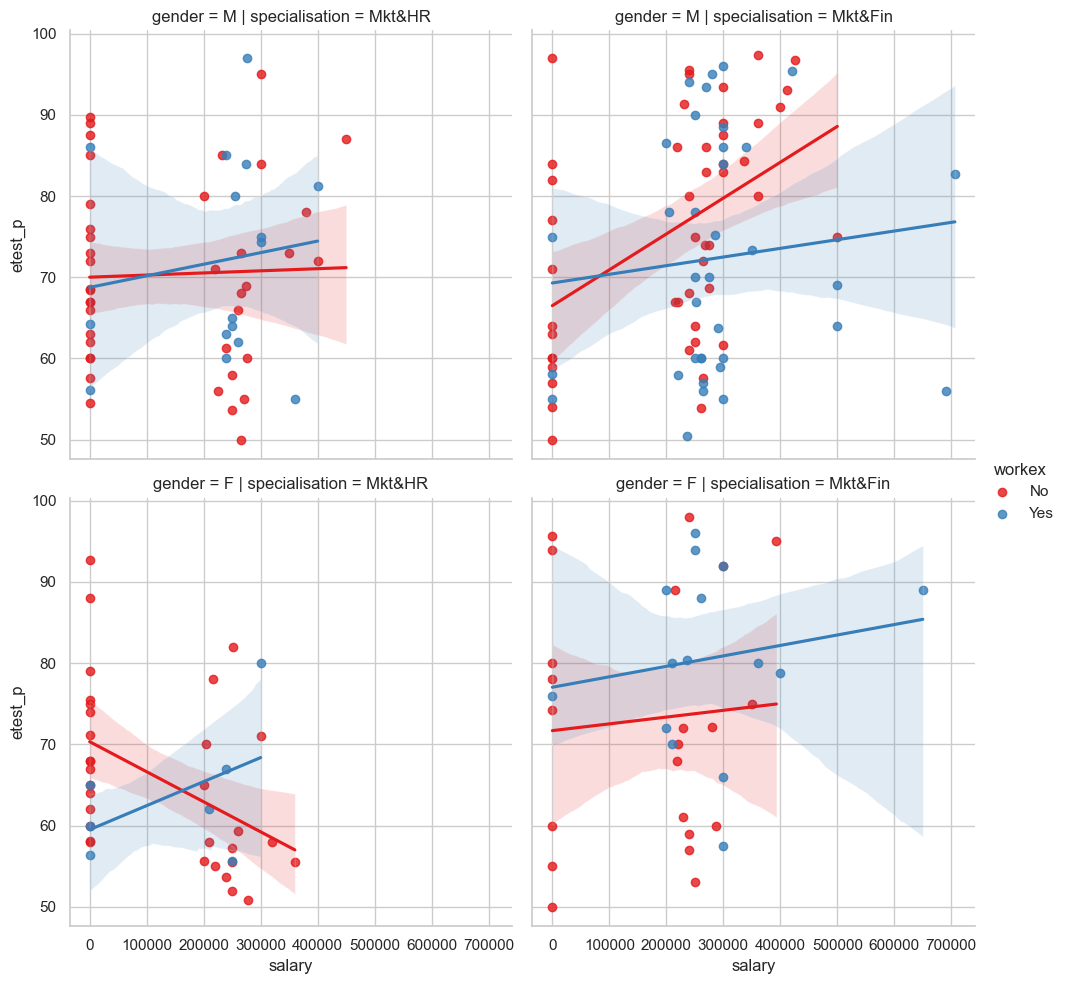

In [23]:
# Bivariate
# Numeric + Numeric / Date

sns.lmplot(data, x='salary', y='etest_p', hue='workex', col='specialisation', row='gender')
plt.show()


### Heatmap

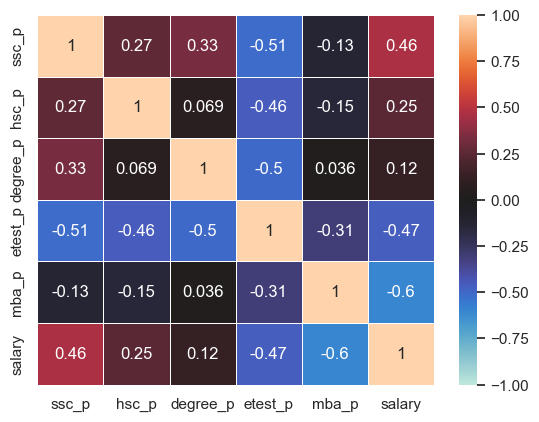

In [24]:
quan, _ = univ.quanQual(data)
corr_data = data[quan].corr()
sns.heatmap(corr_data.corr(), vmax=1, vmin=-1, center=0, annot=True, linewidths=0.5)
plt.show()


### Clustermap

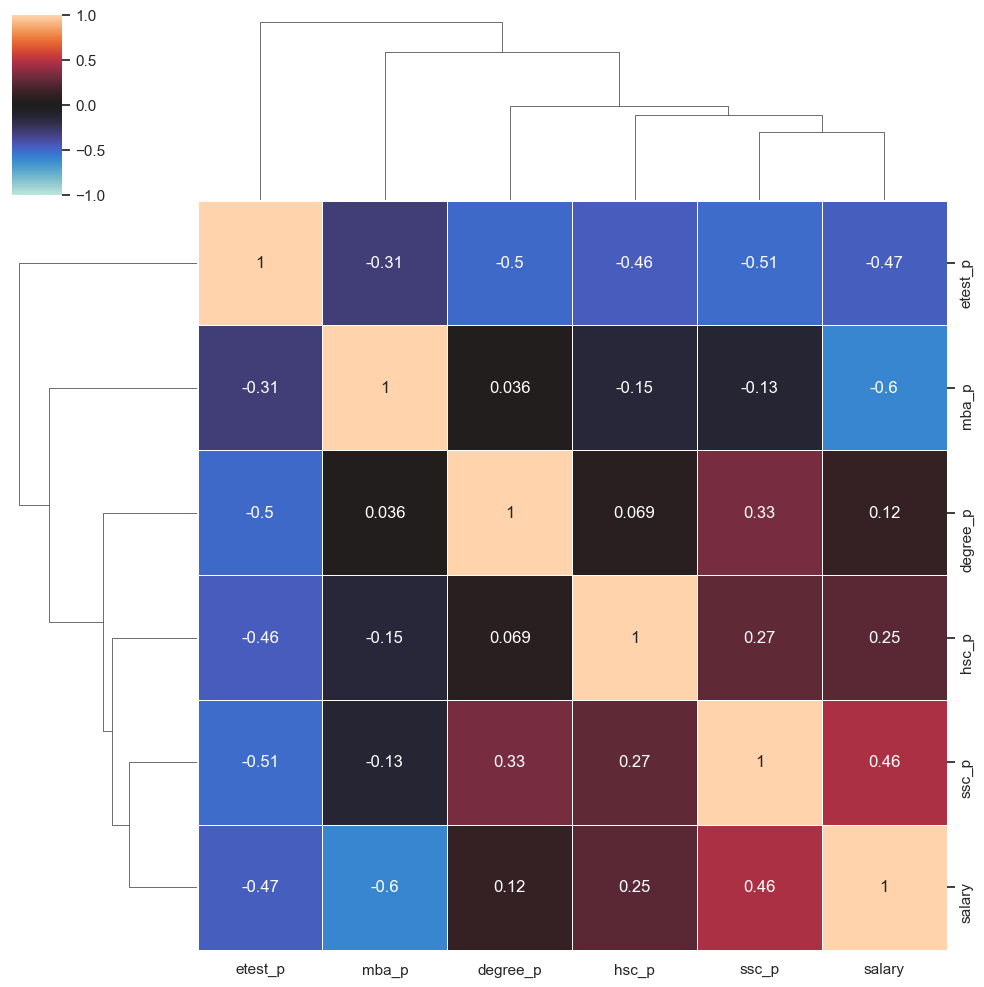

In [25]:
corr_data = data[quan].corr()
sns.clustermap(corr_data.corr(), annot=True, linewidths=0.5, vmax=1, vmin=-1, center=0)
plt.show()


### FacetGrid Plots

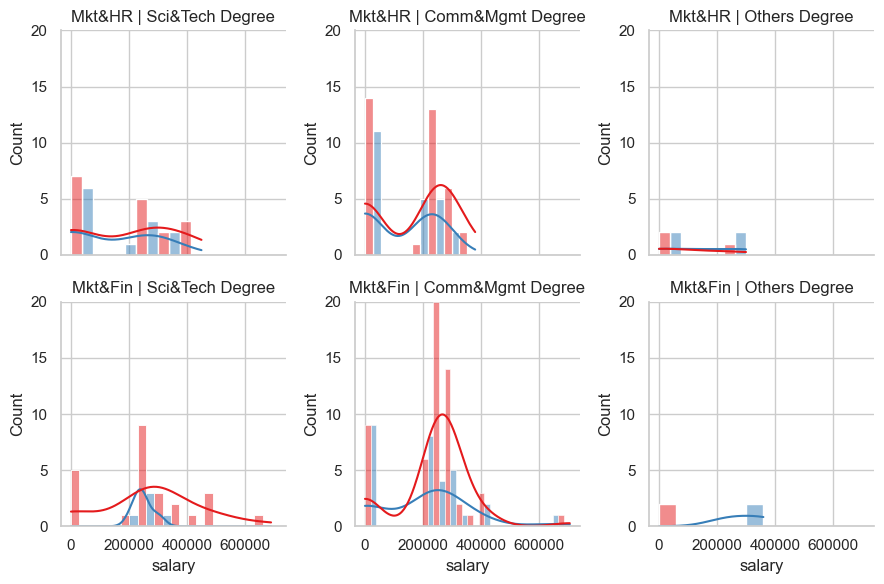

In [26]:
fig1 = sns.FacetGrid(data, col='degree_t', row='specialisation', sharey=False, ylim=(0,20))
fig1.map_dataframe(sns.histplot, 'salary', kde=True, hue='gender', multiple='dodge')
fig1.set_titles( col_template='{col_name} Degree', row_template= '{row_name}')
